In [1]:
# Cell 1: Setup and Imports
import sys
import os
import logging
from dynawo_notebooks.Scripts.core.visualizer import NetworkVisualizer
from dynawo_notebooks.Scripts.core.mo_topology import MoTopologyToolkit
from dynawo_notebooks.Scripts.core.powerflow import PowerFlowRunner
from IPython.display import SVG, display, HTML

# Configure notebook logging to show INFO messages
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S"
)

# Add Scripts directory to path
current_dir = os.getcwd()
scripts_path = os.path.join(current_dir, "../Scripts")
if scripts_path not in sys.path:
    sys.path.append(scripts_path)

# Configurations
SOURCE_DIR = "../Models"
MODEL_NAME = "Dynawo.Examples.Nordic.TestCases.LoadFlow"
DYNAWO_PKG = "/home/guiu/Projects/Dynawo/nightly/dynawo/ddb/Dynawo/package.mo"
LOCAL_FILES = ["FullStaticModel.mo", "LoadFlow.mo", "Network.mo", "NetworkWithPQLoads.mo"]
JSON_MODELS_PATH = "Models/parsed_models_data.json"

print("Toolkit loaded.")

Toolkit loaded.


In [2]:
# Instantiate the Toolkit (Facade)
toolkit = MoTopologyToolkit(SOURCE_DIR, MODEL_NAME, DYNAWO_PKG, LOCAL_FILES)

# Execute Parsing Pipeline
parsed_data = toolkit.parse_electrical_data()
# Export for verification
toolkit.export_to_standard_json(parsed_data, "grid_export_Nordic.json")

# Import for verification
# parsed_data = toolkit.import_from_standard_json("grid_export_Nordic.json")

print(f"Parsing successful. Found {len(parsed_data['generators'])} generators.")

10:57:42 [INFO] ============================================================
10:57:42 [INFO] Initializing MoTopologyToolkit for model: Dynawo.Examples.Nordic.TestCases.LoadFlow
10:57:42 [INFO] ============================================================
10:57:42 [INFO] Connecting to OpenModelica Compiler (OMC)...
10:57:42 [INFO] Local OMC Server is up and running at ZMQ port tcp://127.0.0.1:46643 pid=16234
10:57:42 [INFO] OMC Session established successfully.
10:57:42 [INFO] Loading Standard Modelica Libraries...
10:57:43 [INFO] Loading Dynawo Package from: /home/guiu/Projects/Dynawo/nightly/dynawo/ddb/Dynawo/package.mo
10:57:43 [INFO] Loading 4 local files from /home/guiu/Projects/dynawo-notebooks/src/dynawo_notebooks/Models...
10:57:44 [INFO] Checking model: Dynawo.Examples.Nordic.TestCases.LoadFlow
10:57:44 [WARNING] [OMC log for 'sendExpression(checkModel(Dynawo.Examples.Nordic.TestCases.LoadFlow), True)']: [translation:warning:150] Connector UPu is not balanced: The number of pote

Parsing successful. Found 20 generators.


In [3]:
# Cell 3: Build PowSybl Network

network = toolkit.build_powsybl_network(parsed_data)

print("Network constructed successfully.")
print(f"- Buses: {len(network.get_buses())}")
print(f"- Lines: {len(network.get_lines())}")
print(f"- Generators: {len(network.get_generators())}")
print(f"- Loads: {len(network.get_loads())}")
print(f"- Shunts: {len(network.get_shunt_compensators())}")
print(f"- Transformers: {len(network.get_2_windings_transformers())}")

10:59:23 [INFO] >>> STEP 2: CONVERTING TO POWSYBL
10:59:23 [INFO] Initializing PyPowSybl Network construction...


Network constructed successfully.
- Buses: 74
- Lines: 52
- Generators: 20
- Loads: 22
- Shunts: 11
- Transformers: 50


10:59:23 [INFO] Generating full system visualization diagrams...


Rendering Network Diagrams...


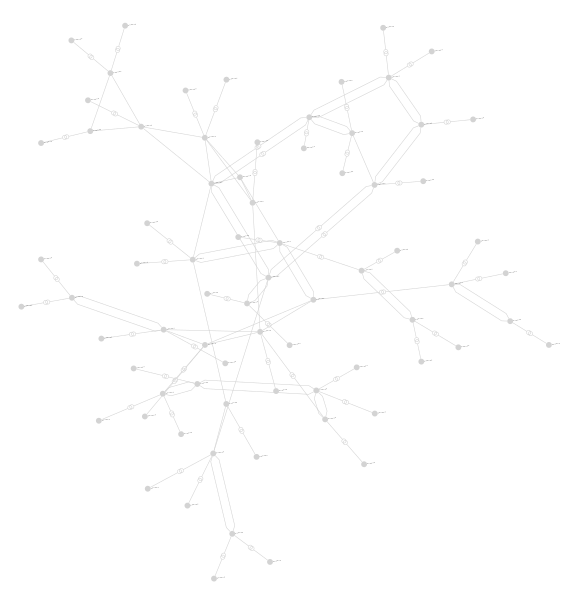

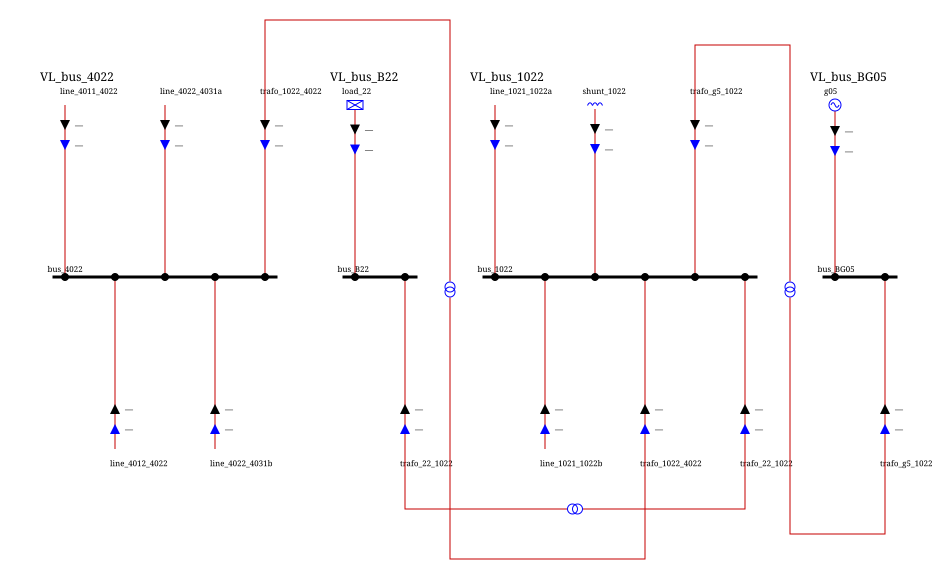

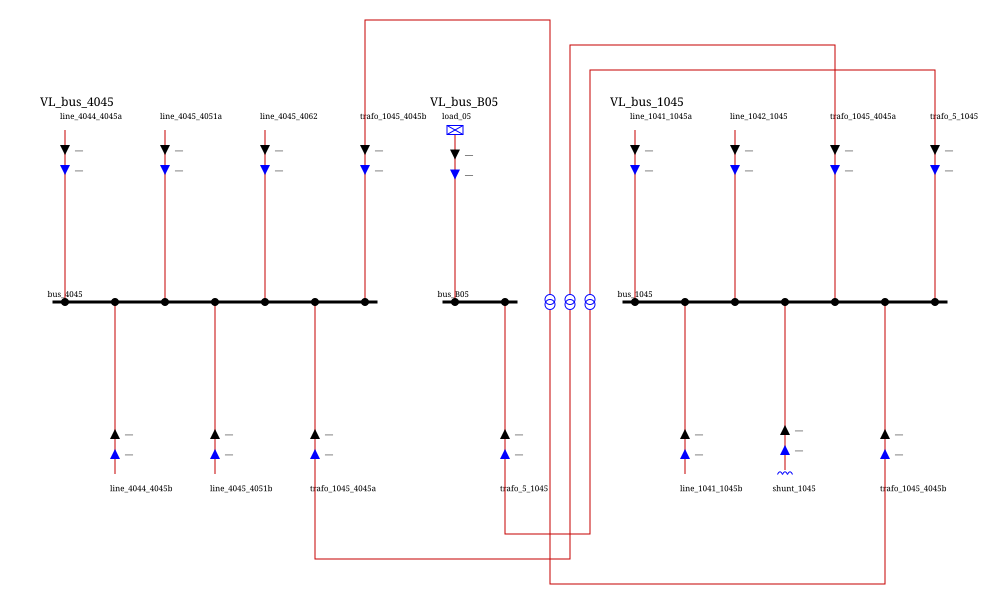

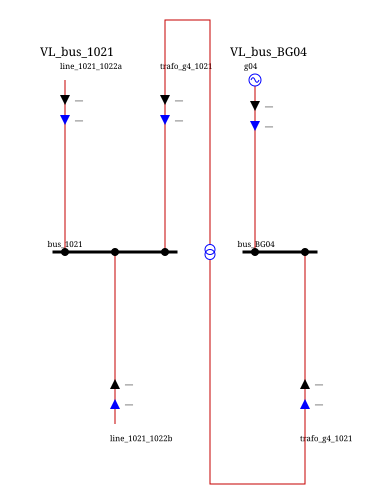

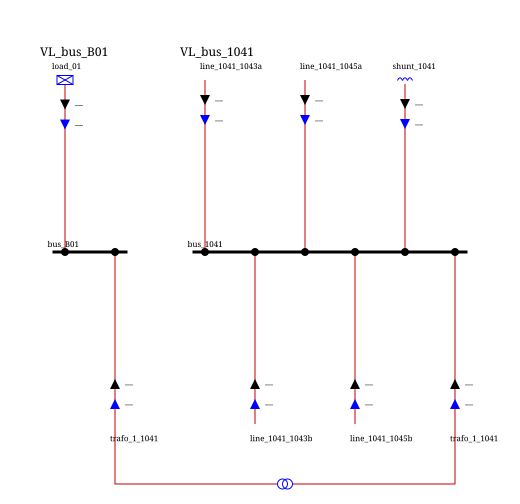

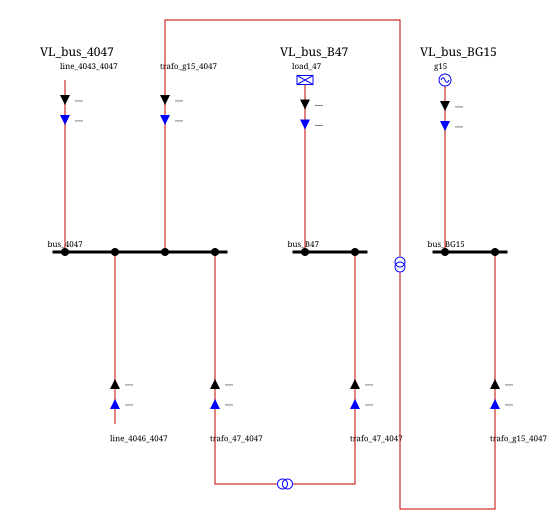

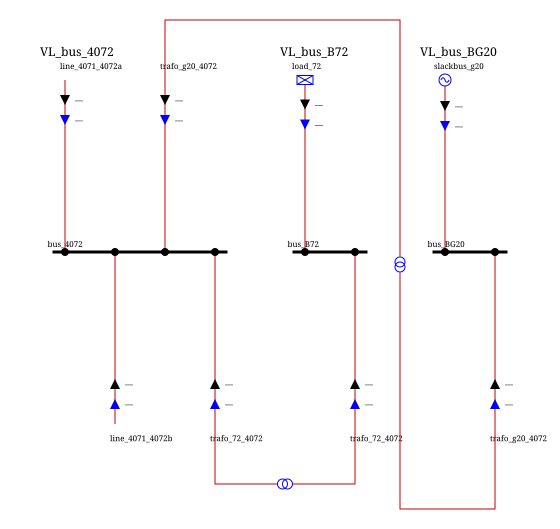

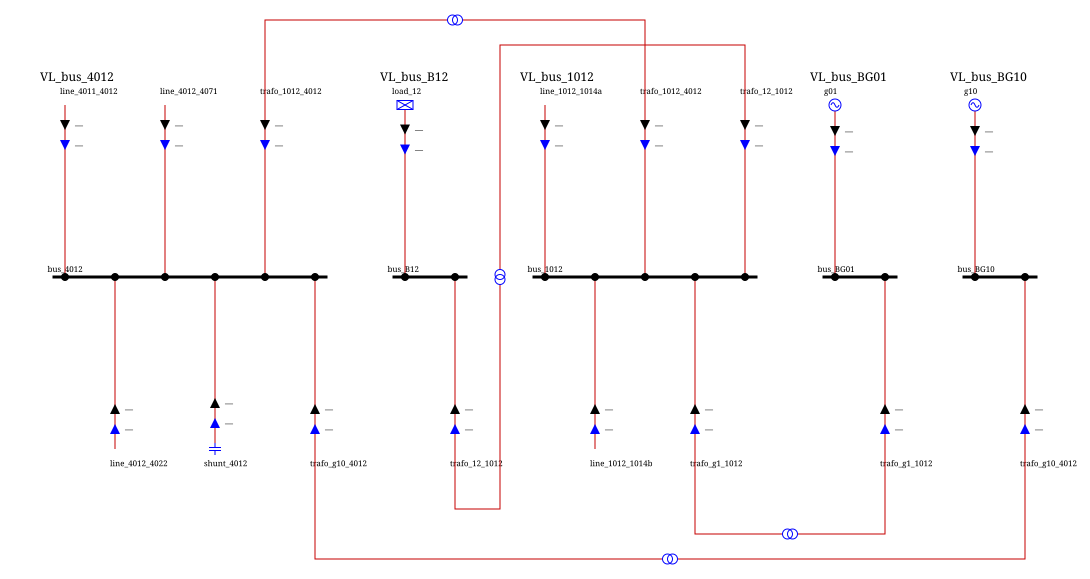

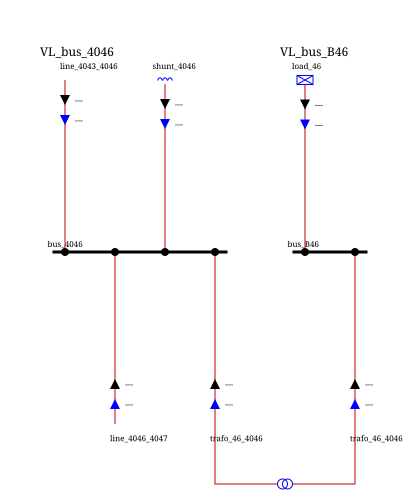

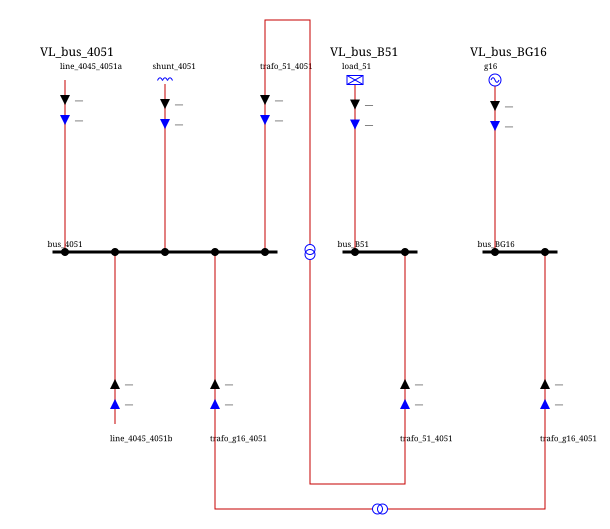

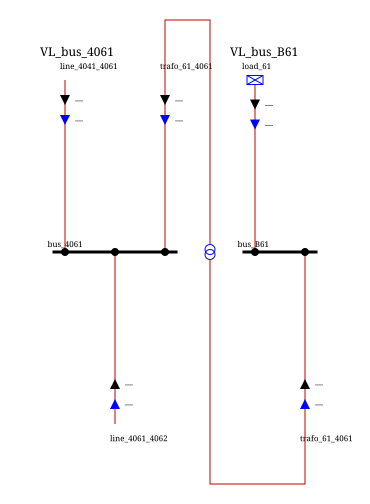

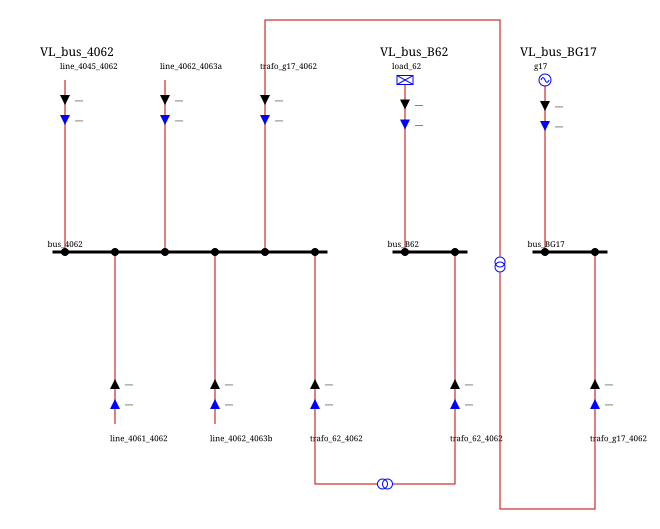

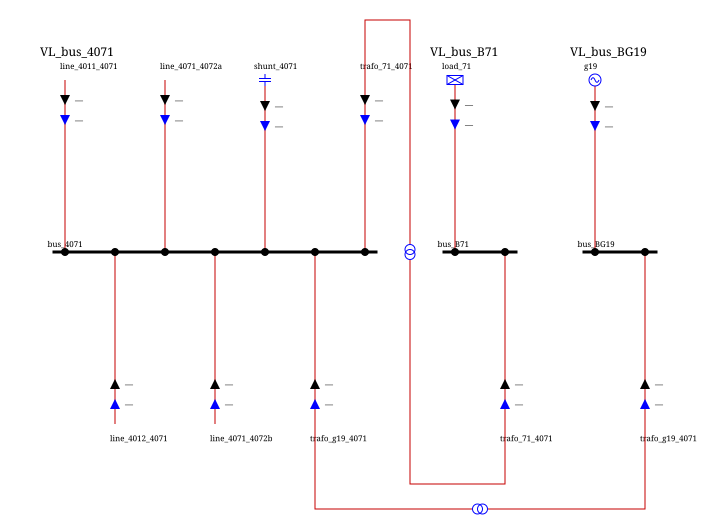

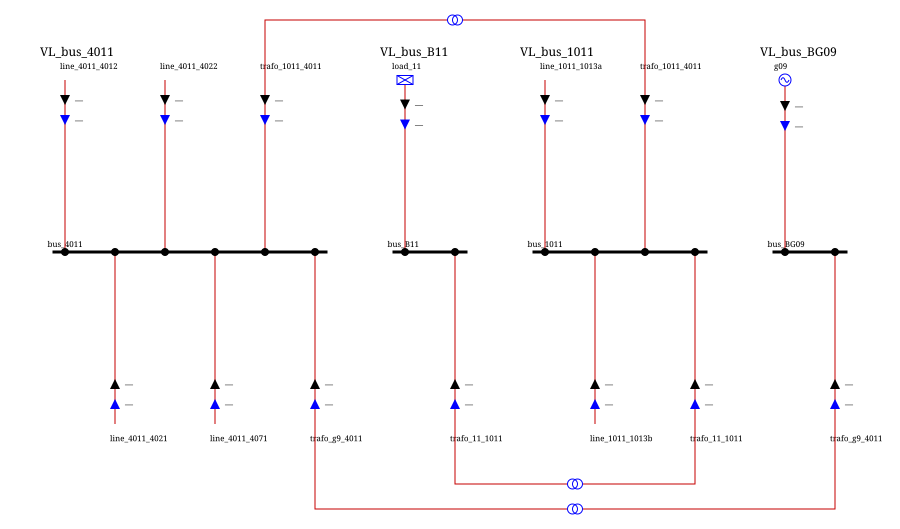

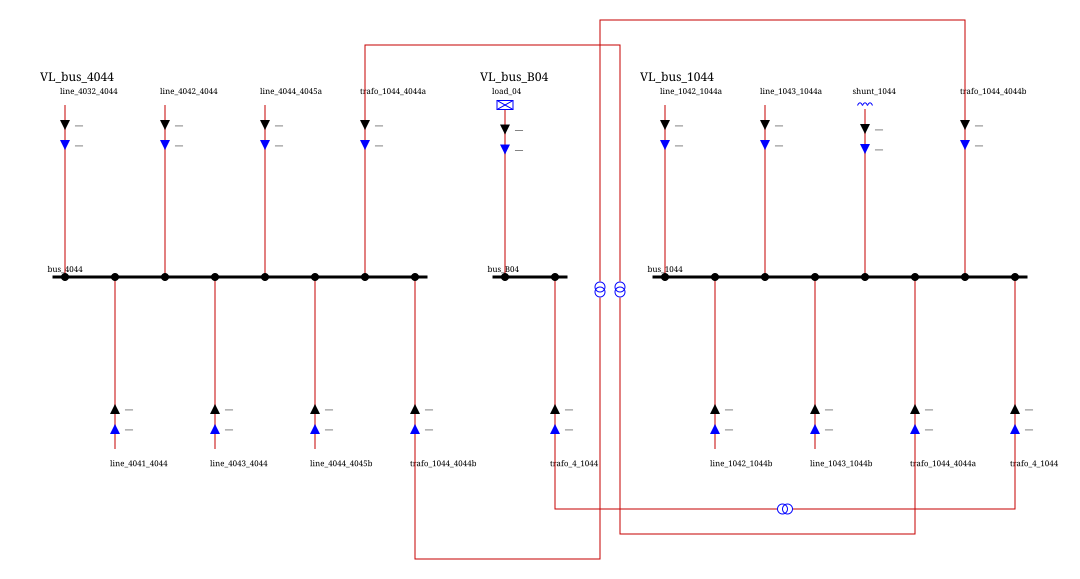

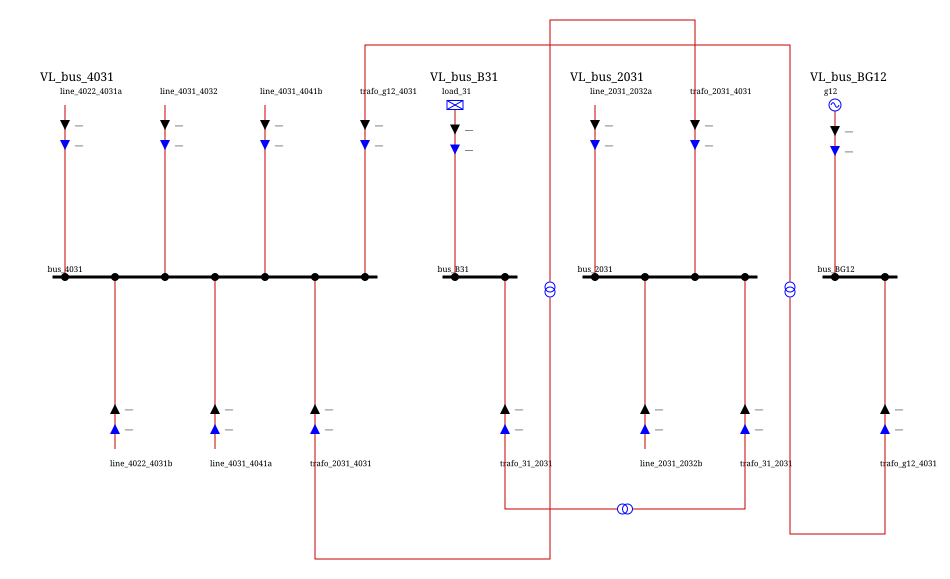

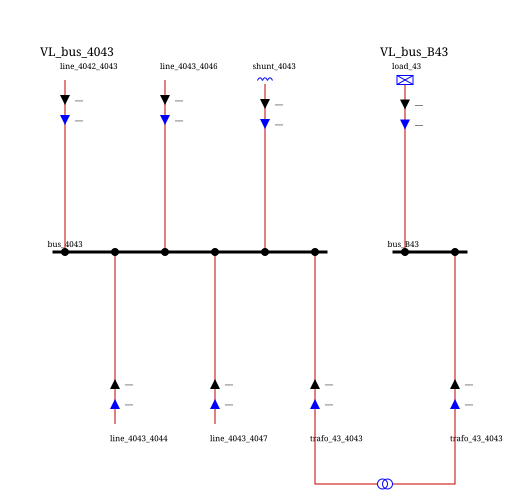

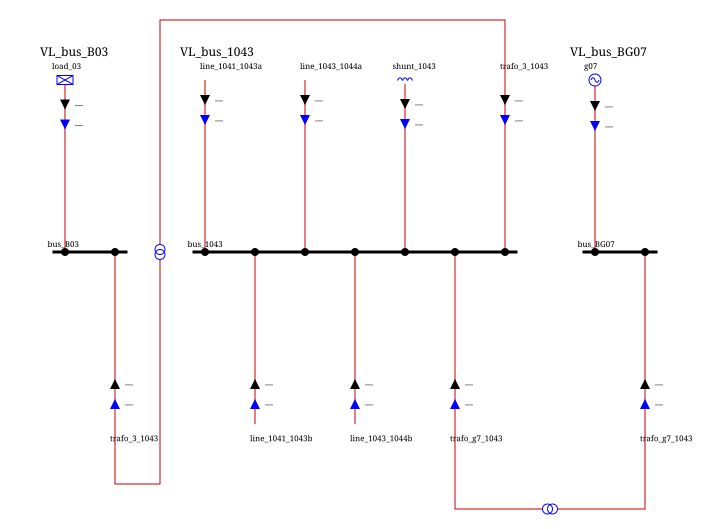

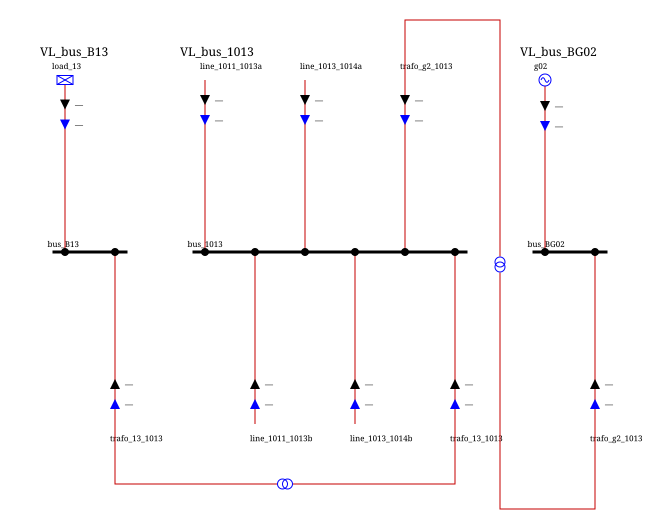

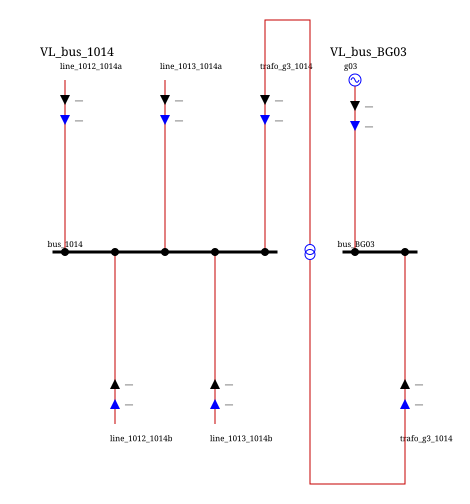

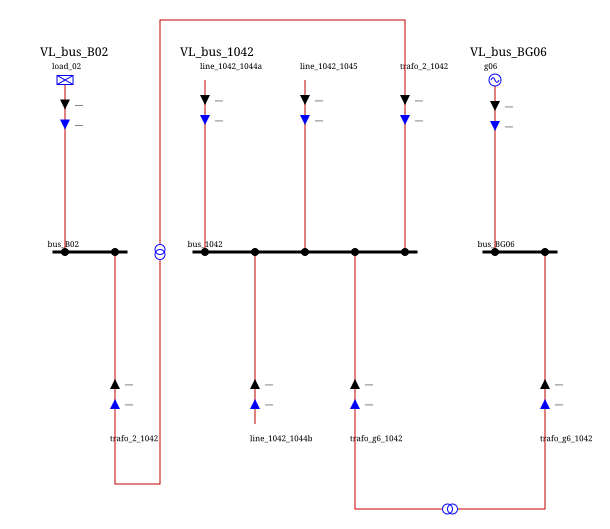

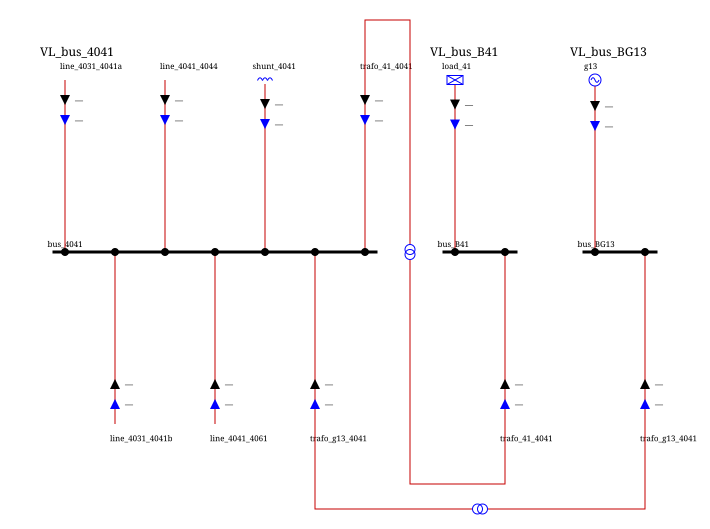

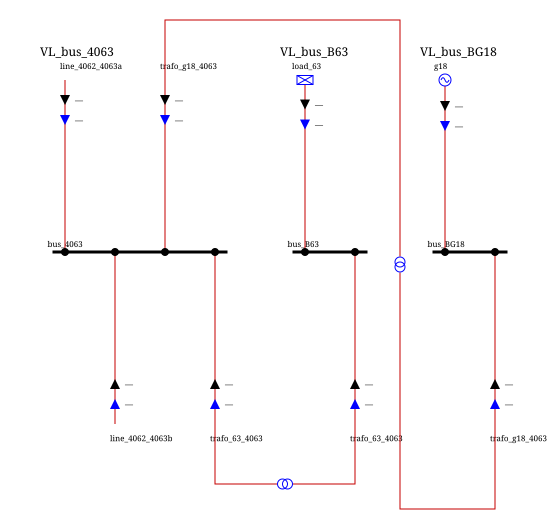

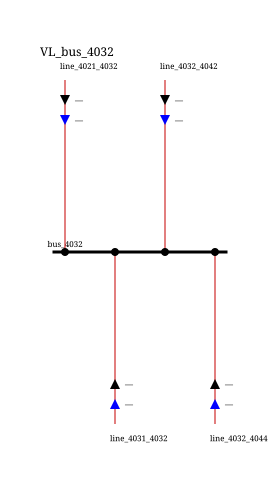

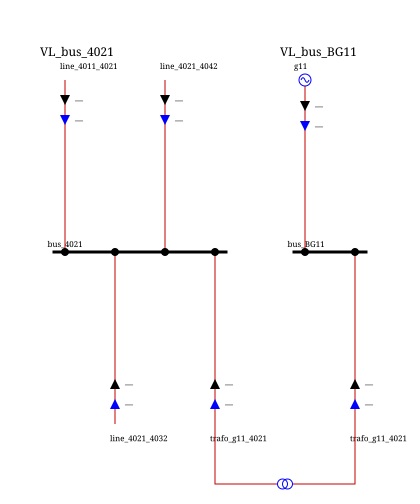

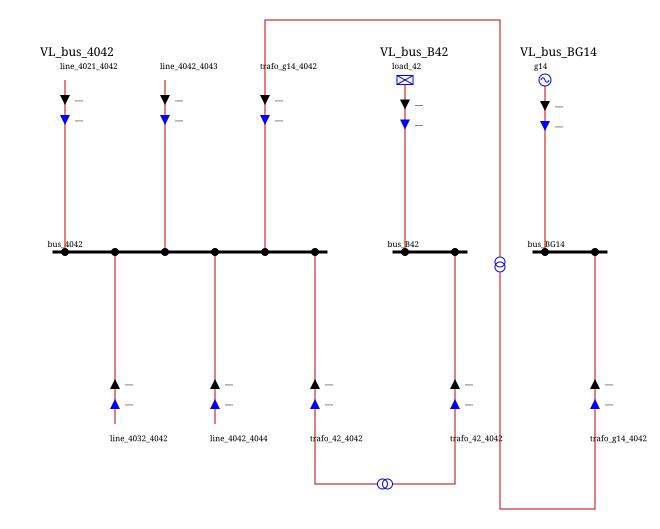

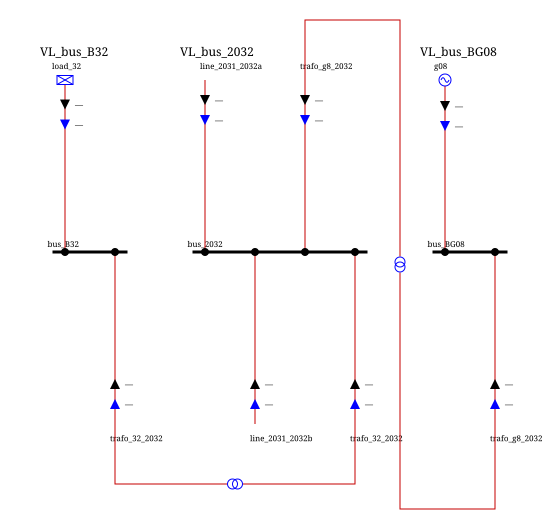

In [4]:
# Cell 4: Network Visualization

print("Rendering Network Diagrams...")
diagrams = NetworkVisualizer.generate_full_system_diagrams(network)

# 1. Display Macro View
if "network_area" in diagrams:
    display(HTML("<h3>Macro View: Network Area (Lines & Substations)</h3>"))
    display(SVG(str(diagrams["network_area"])))

# 2. Display Micro Views (Generators, Loads, etc.)
display(HTML("<h3>Micro View: Substations Details (Generators visible)</h3>"))
for name, svg in diagrams.items():
    if name != "network_area":
        display(HTML(f"<b>Substation: {name}</b>"))
        display(SVG(str(svg)))

In [5]:
# Cell 5: AC Load Flow Execution and Results
from dynawo_notebooks.Scripts.core.powerflow import PowerFlowRunner
from IPython.display import display

print("Starting AC Load Flow analysis...")

# 1. Execute the Load Flow
is_converged = PowerFlowRunner.run_ac_loadflow(network)

if is_converged:
    print("\nSUCCESS: Load flow CONVERGED!")

    # 2. Extract Bus Data (Voltages and Angles)
    print("\n--- BUS RESULTS (Voltages & Angles) ---")
    try:
        buses_df = network.get_buses()
        # In newer versions, we focus on voltage magnitude and angle
        # P and Q injections are viewed at the equipment level or via 'v_mag'/'v_angle'
        columns_buses = ["v_mag", "v_angle"]
        display(buses_df[columns_buses])
    except Exception as e:
        print(f"Could not retrieve Bus results: {e}")

    # 3. Extract Generator Data (To see P and Q output)
    print("\n--- GENERATOR RESULTS (Active & Reactive Power) ---")
    try:
        gens_df = network.get_generators()
        # 'p' and 'q' are the calculated values after loadflow
        columns_gens = ["bus_id", "p", "q", "target_p", "target_v"]
        display(gens_df[columns_gens])
    except Exception as e:
        print(f"Could not retrieve Generator results: {e}")

    # 4. Extract Line Data
    print("\n--- LINE RESULTS (Power Flows & Currents) ---")
    try:
        lines_df = network.get_lines()
        columns_lines = ["bus1_id", "bus2_id", "p1", "q1", "p2", "q2", "i1", "i2"]
        display(lines_df[columns_lines])
    except Exception as e:
        print(f"Could not retrieve Line results: {e}")

else:
    print("\nFAILED: Load flow did NOT converge.")

10:59:24 [INFO] Starting AC Load Flow calculation (OpenLoadFlow)...
10:59:24 [INFO] Auto-detected Slack Bus: VL_bus_BG20_0 (from generator slackbus_g20)
10:59:24 [INFO] SUCCESS: Load flow CONVERGED.


Starting AC Load Flow analysis...

SUCCESS: Load flow CONVERGED!

--- BUS RESULTS (Voltages & Angles) ---


,v_mag,v_angle
id,,
VL_bus_B01_0,217.942423,-10.387662
VL_bus_B02_0,217.366004,-11.160856
VL_bus_B03_0,212.002126,-11.958140
VL_bus_B04_0,215.776512,-10.556197
VL_bus_B05_0,217.619520,-10.531292
...,...,...
VL_bus_4061_0,405.874662,-1.021031
VL_bus_4062_0,405.126766,-0.950573
VL_bus_4063_0,411.784218,-0.821437



--- GENERATOR RESULTS (Active & Reactive Power) ---


,bus_id,p,q,target_p,target_v
id,,,,,
slackbus_g20,VL_bus_BG20_0,-1691.500001,1144.833934,1.0,20.370
g01,VL_bus_BG01_0,-600.000000,-4417.934340,600.0,21.368
g02,VL_bus_BG02_0,-300.000000,-2146.433141,300.0,21.130
g03,VL_bus_BG03_0,-550.000000,-1712.917413,550.0,21.190
g04,VL_bus_BG04_0,-400.000000,-762.073003,400.0,20.678
g05,VL_bus_BG05_0,-200.000000,-232.924527,200.0,20.588
g06,VL_bus_BG06_0,-360.000000,902.352124,360.0,20.168
g07,VL_bus_BG07_0,-180.000000,199.358436,180.0,20.282
g08,VL_bus_BG08_0,-750.000000,-798.979686,750.0,20.996



--- LINE RESULTS (Power Flows & Currents) ---


,bus1_id,bus2_id,p1,q1,p2,q2,i1,i2
id,,,,,,,,
line_1011_1013a,VL_bus_1011_0,VL_bus_1013_0,-277.690113,-1717.928257,277.690113,1746.598238,7519.859423,7519.859423
line_1011_1013b,VL_bus_1011_0,VL_bus_1013_0,-277.690113,-1717.928257,277.690113,1746.598238,7519.859423,7519.859423
line_1012_1014a,VL_bus_1012_0,VL_bus_1014_0,-97.309887,-131.378683,97.309887,131.621104,691.482575,691.482575
line_1012_1014b,VL_bus_1012_0,VL_bus_1014_0,-97.309887,-131.378683,97.309887,131.621104,691.482575,691.482575
line_1013_1014a,VL_bus_1013_0,VL_bus_1014_0,-177.690113,-712.581965,177.690113,717.525846,3122.698457,3122.698457
line_1013_1014b,VL_bus_1013_0,VL_bus_1014_0,-177.690113,-712.581965,177.690113,717.525846,3122.698457,3122.698457
line_1021_1022a,VL_bus_1021_0,VL_bus_1022_0,200.000000,378.986279,-200.000000,-377.253841,1848.523015,1848.523015
line_1021_1022b,VL_bus_1021_0,VL_bus_1022_0,200.000000,378.986279,-200.000000,-377.253841,1848.523015,1848.523015
line_1041_1043a,VL_bus_1041_0,VL_bus_1043_0,-130.898368,69.101793,130.898368,-68.890640,645.349267,645.349267


In [6]:
# Cell 6: Cross-Validation with OpenModelica (OMPython)
from dynawo_notebooks.Scripts.core.comparison import LoadFlowComparator

print("Running Ground Truth Validation...")
print("1. Compiling and simulating the Modelica model via OMC...")

# This will trigger the OMC compiler to solve the non-linear system (t=0.0)
# It might take ~10-30 seconds depending on the Nordic 32 complexity.
comparison_df = LoadFlowComparator.compare_voltages(
    network=network, connector=toolkit.connector, model_name=MODEL_NAME, parsed_data=parsed_data
)

if not comparison_df.empty:
    print("\nSUCCESS: Validation completed! Showing top discrepancies (sorted by Δ V):")

    # Highlight cells with an error larger than 0.001 pu (0.1%)
    def highlight_errors(val):
        color = "red" if isinstance(val, (int, float)) and val > 0.001 else "black"
        return f"color: {color}"

    # Apply style to error columns (CAMBIADO a .map)
    styled_df = comparison_df.style.map(
        highlight_errors, subset=["Δ V (pu)", "Δ Theta (deg)"]
    ).format("{:.4f}", na_rep="N/A")

    display(styled_df)

    # Print summary metrics
    mean_v_err = comparison_df["Δ V (pu)"].mean()
    mean_th_err = comparison_df["Δ Theta (deg)"].mean()
    print(f"\n--- Benchmark Summary ---")
    print(f"Average Voltage Mismatch: {mean_v_err:.6f} pu")
    print(f"Average Angle Mismatch:   {mean_th_err:.6f} deg")
else:
    print("Validation failed. Could not retrieve comparison data.")

10:59:24 [INFO] Initiating cross-platform Load Flow comparison...
10:59:24 [INFO] Starting OMC simulation for 'Dynawo.Examples.Nordic.TestCases.LoadFlow' (stopTime=0.0). This may take a moment...


Running Ground Truth Validation...
1. Compiling and simulating the Modelica model via OMC...


10:59:35 [WARNING] [OMC log for 'sendExpression(simulate(Dynawo.Examples.Nordic.TestCases.LoadFlow, stopTime=0.0), True)']: [translation:warning:150] Connector UPu is not balanced: The number of potential variables (1) is not equal to the number of flow variables (0).
10:59:35 [WARNING] [OMC log for 'sendExpression(simulate(Dynawo.Examples.Nordic.TestCases.LoadFlow, stopTime=0.0), True)']: [translation:warning:150] Connector switchOffSignal1 is not balanced: The number of potential variables (1) is not equal to the number of flow variables (0).
10:59:35 [WARNING] [OMC log for 'sendExpression(simulate(Dynawo.Examples.Nordic.TestCases.LoadFlow, stopTime=0.0), True)']: [translation:warning:150] Connector switchOffSignal2 is not balanced: The number of potential variables (1) is not equal to the number of flow variables (0).
10:59:35 [WARNING] [OMC log for 'sendExpression(simulate(Dynawo.Examples.Nordic.TestCases.LoadFlow, stopTime=0.0), True)']: [translation:warning:150] Connector switchO


SUCCESS: Validation completed! Showing top discrepancies (sorted by Δ V):


,V_OM (pu),V_PPS (pu),Δ V (pu),Theta_OM (deg),Theta_PPS (deg),Δ Theta (deg)
Bus,,,,,,
bus_B03,0.9974,0.9422,0.0552,-79.9662,-11.9581,68.0080
bus_B51,0.9978,1.0451,0.0473,-73.8396,-2.2285,71.6112
bus_B11,1.0026,0.9553,0.0472,-9.4474,-9.2549,0.1925
bus_4062,1.0560,1.0128,0.0432,-54.3558,-0.9506,53.4052
bus_B47,0.9950,1.0377,0.0427,-62.3761,-1.8045,60.5716
bus_B42,0.9952,1.0370,0.0417,-60.2158,-1.6979,58.5179
bus_B04,0.9996,0.9590,0.0406,-70.6710,-10.5562,60.1148
bus_4072,1.0590,1.0186,0.0404,-3.9771,-0.0086,3.9685
bus_B32,0.9978,1.0358,0.0381,-26.7719,-2.4937,24.2782



--- Benchmark Summary ---
Average Voltage Mismatch: 0.016242 pu
Average Angle Mismatch:   37.617496 deg


In [7]:
# Cell 7: Dynamic Model Linking
from dynawo_notebooks.Scripts.core.model_linker import link_models

# Path to the JSON file generated by the XML parser utility
# This file contains the registry of available dynamic models
JSON_MODELS_PATH = "../Models/parsed_models_data.json"

print("Starting dynamic model linking process...")

try:
    # This function associates static elements (IIDM) with dynamic models (Modelica)
    # mapping is an object containing the ModelMapping result
    mapping = link_models(network, JSON_MODELS_PATH)

    if mapping is not None:
        print("SUCCESS: Dynamic models have been linked to the network elements.")
    else:
        print("WARNING: Model linking returned None. Check if the JSON path is correct.")

except Exception as e:
    print(f"CRITICAL ERROR during model linking: {e}")

10:59:37 [WARNING] DISCLAIMER: Element 'slackbus_g20' type '' not in registry. Using fallback: 'Dynawo.Electrical.Machines.OmegaRef.GeneratorSynchronous'.
10:59:37 [WARNING] DISCLAIMER: Element 'g01' type '' not in registry. Using fallback: 'Dynawo.Electrical.Machines.OmegaRef.GeneratorSynchronous'.
10:59:37 [WARNING] DISCLAIMER: Element 'g02' type '' not in registry. Using fallback: 'Dynawo.Electrical.Machines.OmegaRef.GeneratorSynchronous'.
10:59:37 [WARNING] DISCLAIMER: Element 'g03' type '' not in registry. Using fallback: 'Dynawo.Electrical.Machines.OmegaRef.GeneratorSynchronous'.
10:59:37 [WARNING] DISCLAIMER: Element 'g04' type '' not in registry. Using fallback: 'Dynawo.Electrical.Machines.OmegaRef.GeneratorSynchronous'.
10:59:37 [WARNING] DISCLAIMER: Element 'g05' type '' not in registry. Using fallback: 'Dynawo.Electrical.Machines.OmegaRef.GeneratorSynchronous'.
10:59:37 [WARNING] DISCLAIMER: Element 'g06' type '' not in registry. Using fallback: 'Dynawo.Electrical.Machines.O

Starting dynamic model linking process...
SUCCESS: Dynamic models have been linked to the network elements.
